# Eksempel på hvordan man kan gjøre modellering i SOK-1305

# Modellering med Hitters-datasettet

I denne notebooken skal vi bruke `Hitters`-datasettet fra pakken `ISLP`.

Datasettet inneholder statistikk for baseballspillere fra 1986-sesongen, samt informasjon om spillernes lønn (`Salary`) i 1987.

Vi skal bruke datasettet til å undersøke tre forskjellige typer modeller:

1. **Lineær regresjon** (dette kan vi)
   - Predikere en spillers lønn.

2. **Logistisk regresjon** (dette kan vi)
   - Klassifisere spillere som `HighSalary` eller `LowSalary`.

3. **Beslutningstrær** (dette skal vi lære)
   - Predikere lønn ved hjelp av et regresjonstre.
   - Klassifisere spillere ved hjelp av et klassifikasjonstre.
   - Går ikke igjennom i dette dokumentet, men dere kan prøve selv etter vi har gått igjennom stoffet.

Et sentralt poeng er at det samme datasettet kan brukes til forskjellige typer problemer i statistisk læring.

Det er først og fremst **typen responsvariabel** $Y$ som avgjør om vi har et:

- regresjonsproblem
- klassifikasjonsproblem

In [ ]:
# Hvis du ikke allerede har lastet ned ISLP, kan du gjøre det ved å kjøre følgende kommando
%pip install ISLP

## Importere nødvendige pakker

Vi starter med å importere pakkene vi skal bruke.

Vi bruker:

- `pandas` for å arbeide med datasett.
- `numpy` for numeriske beregninger.
- `ISLP` for å laste inn datasettet.
- `scikit-learn` for maskinlæring og modellering.
- `matplotlib` for visualisering.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ISLP import load_data

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.pipeline import Pipeline

# Lineær regresjon (her bruker vi sklearn, boka bruker mye statsmodels også ofte kalt 'sm')
from sklearn.linear_model import LinearRegression

# Logistisk regresjon - vil gjennomgås lenger ned i dokumentet
from sklearn.linear_model import LogisticRegression

# Beslutningstrær - hvis dere vil bruke det
from sklearn.tree import (
    DecisionTreeRegressor,
    DecisionTreeClassifier,
    plot_tree
)

# Evalueringsmål/metrikker
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [4]:
# Henter dataene
Hitters = load_data('Hitters')
Hitters.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


## Vi inspiserer litt greier om dataene

In [5]:
# Noe generell info om obs. og antall variabler
print("Antall observasjoner:", Hitters.shape[0])
print("Antall variabler:", Hitters.shape[1])

print("\nVariabler:")
print(Hitters.columns)

Antall observasjoner: 322
Antall variabler: 20

Variabler:
Index(['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat',
       'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'League', 'Division',
       'PutOuts', 'Assists', 'Errors', 'Salary', 'NewLeague'],
      dtype='object')


# Undersøker om vi har manglende verdier

Før vi kan modellere `Salary`, må vi undersøke om responsvariabelen inneholder manglende verdier.

Vi kan ikke trene en vanlig supervisert modell dersom responsvariabelen mangler.

Derfor undersøker vi først:

> Hvor mange spillere mangler informasjon om lønn?

In [6]:
Hitters.isnull().sum()

AtBat         0
Hits          0
HmRun         0
Runs          0
RBI           0
Walks         0
Years         0
CAtBat        0
CHits         0
CHmRun        0
CRuns         0
CRBI          0
CWalks        0
League        0
Division      0
PutOuts       0
Assists       0
Errors        0
Salary       59
NewLeague     0
dtype: int64

In [7]:
print(
    "Antall manglende verdier i Salary:",
    Hitters["Salary"].isnull().sum()
)

Antall manglende verdier i Salary: 59


## Fjerne manglende lønnsdata

Siden `Salary` er responsvariabelen vår, kan vi ikke bruke observasjoner hvor lønnen mangler.

Vi fjerner derfor disse observasjonene. (Noen ganger kan man tilegne manglende verdier f.eks. med median -- **hva medfører det?** Kan være aktuelt for enkelte oppgaver?)

Det er viktig å merke seg at vi kun fjerner observasjoner fordi **responsvariabelen mangler**.

Vi skal ikke bruke informasjon fra fremtidige observasjoner for å gjette lønnen dersom målet er å demonstrere vanlig 'supervised learning'.

In [8]:
Hitters = Hitters.dropna(subset=["Salary"])

print("Datasettets størrelse etter fjerning av manglende Salary:")
print(Hitters.shape)

Datasettets størrelse etter fjerning av manglende Salary:
(263, 20)


# Utforske datasettet

Vi undersøker nå hvordan datasettet ser ut.

Vi kan blant annet se på:

- gjennomsnitt
- standardavvik
- minimum og maksimum
- fordelingen av lønn

Dette er en del av den innledende **eksplorative dataanalysen**.

In [9]:
Hitters.describe()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary
count,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000
mean,403.642586,107.828897,11.619772,54.745247,51.486692,41.114068,7.311787,2657.543726,722.186312,69.239544,361.220532,330.418251,260.266160,290.711027,118.760456,8.593156,535.925882
std,147.307209,45.125326,8.757108,25.539816,25.882714,21.718056,4.793616,2286.582929,648.199644,82.197581,331.198571,323.367668,264.055868,279.934575,145.080577,6.606574,451.118681
min,19.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,19.000000,4.000000,0.000000,2.000000,3.000000,1.000000,0.000000,0.000000,0.000000,67.500000
25%,282.500000,71.500000,5.000000,33.500000,30.000000,23.000000,4.000000,842.500000,212.000000,15.000000,105.500000,95.000000,71.000000,113.500000,8.000000,3.000000,190.000000
50%,413.000000,103.000000,9.000000,52.000000,47.000000,37.000000,6.000000,1931.000000,516.000000,40.000000,250.000000,230.000000,174.000000,224.000000,45.000000,7.000000,425.000000
75%,526.000000,141.500000,18.000000,73.000000,71.000000,57.000000,10.000000,3890.500000,1054.000000,92.500000,497.500000,424.500000,328.500000,322.500000,192.000000,13.000000,750.000000
max,687.000000,238.000000,40.000000,130.000000,121.000000,105.000000,24.000000,14053.000000,4256.000000,548.000000,2165.000000,1659.000000,1566.000000,1377.000000,492.000000,32.000000,2460.000000


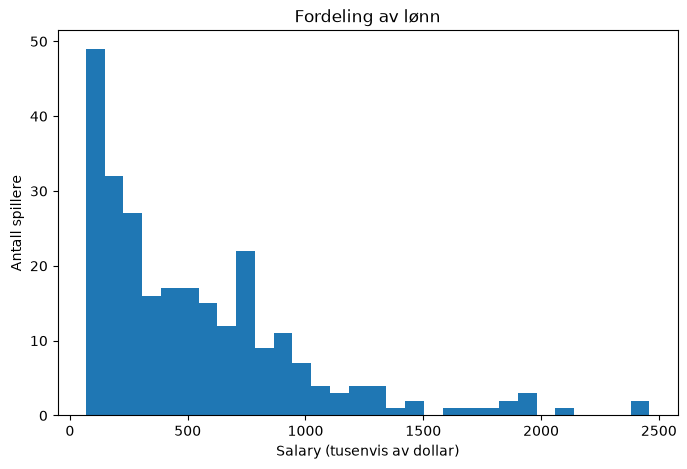

In [11]:
# Denne figuren kan helt klart gjøres penere... :-)

plt.figure(figsize=(8, 5))

plt.hist(Hitters["Salary"], bins=30)

plt.xlabel("Salary (tusenvis av dollar)")
plt.ylabel("Antall spillere")

plt.title("Fordeling av lønn")

plt.show()

# Del 1: Lineær regresjon

Vi starter med et regresjonsproblem.

Spørsmålet vårt er:

> Kan vi predikere en baseballspillers lønn basert på spillerens statistikk?

Responsvariabelen er:

$$
Y = \text{Salary}.
$$

Siden `Salary` er en kontinuerlig numerisk variabel, har vi et **regresjonsproblem**.

Vi bruker derfor lineær regresjon som vår første modell.

## Forklaringsvariabler og responsvariabel

I maskinlæring bruker vi vanligvis:

$$
X
$$

til å representere forklaringsvariablene og

$$
y
$$

til å representere responsvariabelen.

I vårt tilfelle er:

$$
y = \text{Salary}.
$$

Alle de andre variablene brukes som potensielle forklaringsvariabler, matematisk skrevet $$X_j ,\quad j=1, \ldots, p$$

In [33]:
X = Hitters.drop(columns="Salary")

y = Hitters["Salary"]

# Formen på forklaringsvariabel matrisen
print("X:")
print(X.shape)

# En vektor for y'ene våre
print("\ny:")
print(y.shape)

X:
(263, 20)

y:
(263,)


## Numeriske og kategoriske variabler

Datasettet inneholder både:

### Numeriske variabler

Eksempler:

- `Hits`
- `HmRun`
- `Years`
- `CAtBat`

### Kategoriske variabler

Eksempler:

- `League`
- `Division`
- `NewLeague`

Maskinlæringsalgoritmer som lineær regresjon kan ikke direkte bruke tekstkategorier som `A`, `N`, `E` og `W`.

Vi må derfor transformere kategoriske variabler til numeriske variabler.

Dette gjøres ved hjelp av **One-Hot Encoding**. Dere kan lese mer om One Hot encoding [her](https://www.geeksforgeeks.org/machine-learning/ml-one-hot-encoding/)! :-)

In [34]:
# Håndtering av datatyper -  dette er viktig for å gjennomføre prosjektet deres!!

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns

print("Numeriske variabler:")
print(list(numerical_features))

print("\nKategoriske variabler:")
print(list(categorical_features))

Numeriske variabler:
['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat', 'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists', 'Errors', 'HighSalary']

Kategoriske variabler:
['League', 'Division', 'NewLeague']


# Train-test split

Vi ønsker å evaluere hvor godt modellen fungerer på nye observasjoner.

Derfor deler vi datasettet i:

- **treningsdata**
- **testdata**

Modellen trenes på treningsdataene.

Deretter bruker vi modellen til å predikere lønnen til spillerne i testdatasettet.

Dette gir oss et bedre bilde av modellens evne til å generalisere.

Vi bruker:

- 80 % av dataene til trening
- 20 % av dataene til testing

### Husk til prosjektet
I kapittel 5 har vi diskutert både kryssvalidering og bootstrapping -- det kan være nyttig.

In [14]:
# Splitter dataene våre 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Antall observasjoner i treningsdata:", X_train.shape[0])
print("Antall observasjoner i testdata:", X_test.shape[0])

Antall observasjoner i treningsdata: 210
Antall observasjoner i testdata: 53


# Preprocessing

Før vi kan bruke lineær regresjon, må vi behandle de forskjellige variablene.

Vi bruker en `ColumnTransformer`.

Dette gjør det mulig å:

- behandle numeriske variabler på én måte
- behandle kategoriske variabler på en annen måte

For de kategoriske variablene bruker vi:

```python
OneHotEncoder()
```

Dette lager numeriske indikatorvariabler for de forskjellige kategoriene.

Vi setter handle_unknown="ignore" slik at modellen ikke krasjer dersom den møter en kategori i testdataene som ikke forekommer i treningsdataene. Se funksjonen i neste kodecelle.

In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

# Modellpipeline

Vi lager nå en `Pipeline`.

En pipeline kombinerer flere steg i én modell.

I vårt tilfelle:

$$
\text{Data}
\rightarrow
\text{Preprocessing}
\rightarrow
\text{Lineær regresjon}
$$

Fordelen med en pipeline er at vi sikrer at:

- treningsdata og testdata behandles på samme måte
- preprocessing læres fra treningsdataene
- vi reduserer risikoen for data leakage

In [16]:
# Vår lineære pipeline
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

# Trene den lineære regresjonsmodellen

Vi trener modellen ved hjelp av treningsdataene.

Modellen forsøker å finne en lineær sammenheng mellom:

$$
X_1, X_2, \ldots, X_p
$$

og

$$
Y = \text{Salary}.
$$

Modellen kan skrives som:

$$
Y =
\beta_0
+
\beta_1X_1
+
\beta_2X_2
+
\cdots
+
\beta_pX_p
+
\varepsilon.
$$

In [17]:
# trener modellen på X_tran og y_train
linear_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['AtBat','Hits','HmRun',...,'Assists','Errors','NewLeague']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatena

# Predikere lønn

Når modellen er trent, kan vi bruke den til å predikere lønn for spillerne i testdatasettet.

Vi sammenligner deretter:

- faktisk lønn
- predikert lønn

In [18]:
# Predikerer og får vår y_hat vektor med prediksjoner, basert på X_test
y_pred_linear = linear_model.predict(X_test)

# sammenligner vår prediksjoner med de faktiske verdiene i y_test
results_linear = pd.DataFrame({
    "Actual Salary": y_test.values,
    "Predicted Salary": y_pred_linear
})

# sjekk ut!
results_linear.head(10)

,Actual Salary,Predicted Salary
0,850.000,597.241698
1,277.500,683.906734
2,875.000,899.763674
3,150.000,411.994225
4,260.000,340.343660
5,277.500,335.383100
6,210.000,651.922737
7,140.000,412.820399
8,517.143,879.504003
9,325.000,730.238923


# Evaluering av regresjonsmodellen

Vi bruker tre vanlige evalueringsmål.

## Mean Absolute Error (MAE)

$$
MAE =
\frac{1}{n}
\sum_{i=1}^{n}
|y_i-\hat{y}_i|.
$$

MAE forteller oss den gjennomsnittlige absolutte prediksjonsfeilen.

---

## Root Mean Squared Error (RMSE)

$$
RMSE
=
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
(y_i-\hat{y}_i)^2
}.
$$

RMSE gir større straff til store prediksjonsfeil.

---

## $R^2$

$$
R^2
=
1-
\frac{
\sum(y_i-\hat{y}_i)^2
}{
\sum(y_i-\bar{y})^2
}.
$$

$R^2$ beskriver hvor mye av variasjonen i responsvariabelen som modellen forklarer.

### **Deres jobb er å tolke dette!**

In [19]:
# MAE
mae_linear = mean_absolute_error(
    y_test,
    y_pred_linear
)

# RMSE
rmse_linear = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_linear
    )
)

# R^2
r2_linear = r2_score(
    y_test,
    y_pred_linear
)

# print that shit
print("Lineær regresjon")
print("-------------------")
print(f"MAE:  {mae_linear:.2f}")
print(f"RMSE: {rmse_linear:.2f}")
print(f"R²:   {r2_linear:.3f}")

Lineær regresjon
-------------------
MAE:  211.12
RMSE: 358.17
R²:   0.291


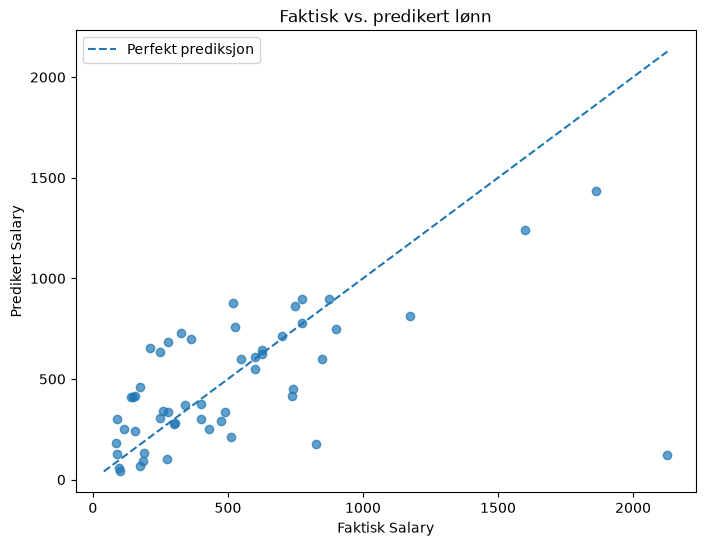

In [35]:
# enkel figur for prediksjons vs faktisk -- kan gjøres mye finere...:-)

plt.figure(figsize=(8, 6))

# Scatterplot
plt.scatter(
    y_test,
    y_pred_linear,
    alpha=0.7
)

# Diagonal referanselinje
min_salary = min(y_test.min(), y_pred_linear.min())
max_salary = max(y_test.max(), y_pred_linear.max())

plt.plot(
    [min_salary, max_salary],
    [min_salary, max_salary],
    linestyle="--",
    label="Perfekt prediksjon"
)

plt.xlabel("Faktisk Salary")
plt.ylabel("Predikert Salary")

plt.title("Faktisk vs. predikert lønn")

plt.legend()

plt.show()

# Residualer

Residualen er forskjellen mellom den faktiske og predikerte verdien:

$$
e_i = y_i - \hat{y}_i.
$$

En positiv residual betyr at modellen har **underestimert** lønnen.

En negativ residual betyr at modellen har **overestimert** lønnen.

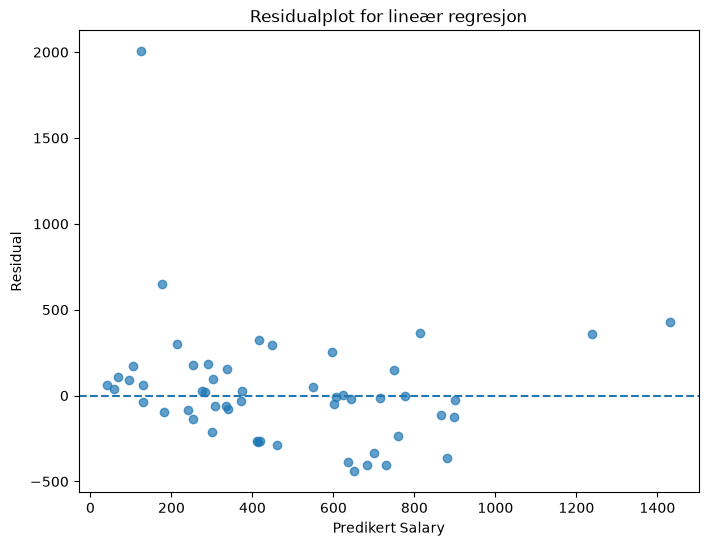

In [21]:
residuals = y_test - y_pred_linear

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred_linear,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predikert Salary")
plt.ylabel("Residual")

plt.title("Residualplot for lineær regresjon")

plt.show()

# **Fra regresjon til klassifikasjon**

# Del 2: Logistisk regresjon

Vi skal nå bruke det samme datasettet til et annet problem.

I stedet for å spørre:

> Hva blir spillerens lønn?

spør vi:

> Har spilleren høy eller lav lønn?

Dette krever at vi lager en ny responsvariabel.

Vi definerer:

$$
\text{HighSalary}
=
\begin{cases}
1, & \text{hvis Salary er høy}\\
0, & \text{hvis Salary er lav}
\end{cases}
$$

Vi bruker medianlønnen som grense.

Spillere med lønn over medianen får:

$$
HighSalary = 1.
$$

Alle andre får:

$$
HighSalary = 0.
$$

In [36]:
# Lager vår responsvariabel Y
salary_median = Hitters["Salary"].median()

Hitters["HighSalary"] = (
    Hitters["Salary"] > salary_median
).astype(int)

print("Median Salary:", salary_median)

Hitters["HighSalary"].value_counts()

Median Salary: 425.0


HighSalary
0    134
1    129
Name: count, dtype: int64

## Klassefordeling

Vi undersøker nå hvor mange spillere som tilhører hver klasse.

En verdi på:

- `0` betyr lav lønn
- `1` betyr høy lønn

Siden vi bruker medianen som grense, forventer vi omtrent like mange observasjoner i hver klasse.

In [24]:
Hitters["HighSalary"].value_counts(normalize=True)

HighSalary
0    0.509506
1    0.490494
Name: proportion, dtype: float64

## **Er det cirka like mange observasjoner i hver kategori?**

# Viktig fjerne `Salary`

### Unngå data leakage

Når vi skal predikere `HighSalary`, må vi være svært forsiktige.

`HighSalary` er laget direkte fra `Salary`.

Derfor kan vi **ikke bruke `Salary` som forklaringsvariabel**. Tenk over selv: **Hvorfor ikke?**

Dersom vi brukte `Salary` for å predikere `HighSalary`, ville modellen i praksis fått tilgang til svaret.

Dette kalles:

> **Data leakage**

Vi fjerner derfor både:

- `Salary`
- `HighSalary`

fra forklaringsvariablene.

In [25]:
X_classification = Hitters.drop(
    columns=[
        "Salary",
        "HighSalary"
    ]
)

y_classification = Hitters["HighSalary"]

# Train-test split for klassifikasjon

Vi deler igjen datasettet i:

- treningsdata
- testdata

Denne gangen bruker vi `stratify=y`.

Dette bidrar til at klassefordelingen blir omtrent lik i:

- treningsdataene
- testdataene

In [26]:
# trening og test splitting
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_classification,
    y_classification,
    test_size=0.20,
    random_state=42,
    stratify=y_classification
)

## La oss begynne logistisk regresjon

# Logistisk regresjon

Logistisk regresjon brukes når responsvariabelen er kategorisk.

Her har vi:

$$
Y \in \{0,1\}.
$$

Modellen forsøker å estimere:

$$
P(Y=1|X).
$$

I vårt tilfelle:

$$
P(
HighSalary = 1
\mid X
).
$$

Logistisk regresjon modellerer log-odds:

$$
\log
\left(
\frac{p(X)}
{1-p(X)}
\right)
=
\beta_0
+
\beta_1X_1
+
\cdots
+
\beta_pX_p.
$$

Deretter transformeres dette til en sannsynlighet mellom 0 og 1.

In [27]:
# Modellen vår 

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)

## Så må vi faktisk "trene" modellen

Vi trener nå den logistiske regresjonsmodellen.

Modellen lærer sammenhengen mellom spillernes statistikk og sannsynligheten for at spilleren har høy lønn.

In [28]:
# trener modellen vår!
logistic_model.fit(
    X_train_class,
    y_train_class
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['AtBat','Hits','HmRun',...,'Assists','Errors','NewLeague']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining co

# Predikere sannsynligheter $\hat{p}$

En logistisk regresjonsmodell predikerer først sannsynligheter.

For eksempel kan modellen predikere:

$$
P(HighSalary=1)=0.82.
$$

Dette betyr at modellen vurderer sannsynligheten for høy lønn til 82 %.

In [29]:
y_prob_logistic = logistic_model.predict_proba(
    X_test_class
)[:, 1]

y_prob_logistic[:10]

array([0.11826341, 0.98999631, 0.02361018, 0.81252996, 0.30638714,
       0.02879701, 0.82866353, 0.08564909, 0.04804735, 0.01914833])

# Fra sannsynlighet til klasse

For å gjøre en sannsynlighet om til en klassifikasjon trenger vi en terskel.

Vi bruker først:

$$
\text{threshold}=0.5.
$$

Da predikerer vi:

$$
\hat{Y}
=
\begin{cases}
1, & p(X) \geq 0.5\\
0, & p(X) < 0.5
\end{cases}
$$

In [30]:
# Hva er grensen for p_hat???
threshold = 0.50

y_pred_logistic = (
    y_prob_logistic >= threshold
).astype(int)

# Confusion matrix

En confusion matrix viser hvordan modellens prediksjoner fordeler seg.

Vi har fire mulige utfall:

| | Faktisk 0 | Faktisk 1 |
|---|---|---|
| Predikert 0 | True Negative | False Negative |
| Predikert 1 | False Positive | True Positive |

Dette gir oss mer informasjon enn bare accuracy.

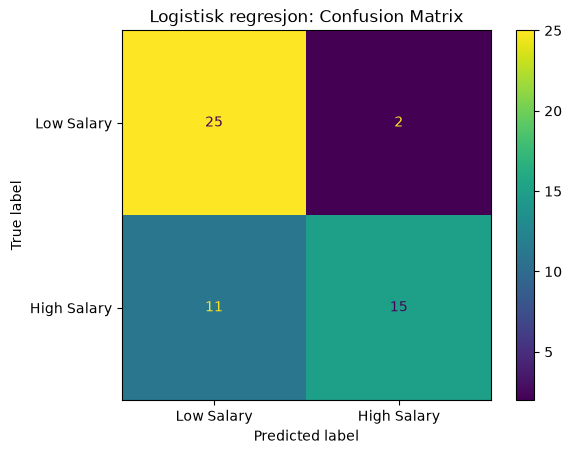

In [31]:
# lager vår confusion matrix!
cm = confusion_matrix(
    y_test_class,
    y_pred_logistic
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Low Salary",
        "High Salary"
    ]
)

display.plot()

plt.title(
    "Logistisk regresjon: Confusion Matrix"
)

plt.show()

# Evaluering av logistisk regresjon

Vi bruker blant annet **accuracy**.

Accuracy er definert som:

$$
Accuracy
=
\frac{
TP+TN
}{
TP+TN+FP+FN
}.
$$

Accuracy forteller oss hvor stor andel av observasjonene modellen klassifiserer riktig.

Vi ser også på:

- Precision
- Recall
- F1-score

Disse har vi gjennomgått i forelesning!

In [32]:
accuracy_logistic = accuracy_score(
    y_test_class,
    y_pred_logistic
)

print(
    f"Accuracy: {accuracy_logistic:.3f}"
)

print("\nClassification report:\n")

print(
    classification_report(
        y_test_class,
        y_pred_logistic,
        target_names=[
            "Low Salary",
            "High Salary"
        ]
    )
)

Accuracy: 0.755

Classification report:

              precision    recall  f1-score   support

  Low Salary       0.69      0.93      0.79        27
 High Salary       0.88      0.58      0.70        26

    accuracy                           0.75        53
   macro avg       0.79      0.75      0.75        53
weighted avg       0.79      0.75      0.75        53



# Dette må dere tolke! :-)

# Dokumentet her er ment som en slags "inspirasjon" på hvordan man kan legge opp en notatbok. 
Men her har jeg gjort ting kjapt, og ikke finskrevet det til en fullverdig rapport. Dere skal ha med kilder, forklare hva som skjer og diskutere resultater. Dere må sjekke kravene for prosjektet her: https://uit-sok-1305-h26.github.io/prosjekt.html 

Lykke til! :-)